In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!gdown 1qTeMPS5UG9FcLzgyfU6vhW2enBTagscp

df = pd.read_csv("data.csv", sep=";", skiprows=3)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1qTeMPS5UG9FcLzgyfU6vhW2enBTagscp
To: /content/data.csv
100% 28.7M/28.7M [00:00<00:00, 57.0MB/s]


,id,sensor_id,value,ts_create,ts_update
0,495019,3.0,-0.841157,1.747512e+09,NaN
1,495020,1.0,-1.382923,1.747512e+09,NaN
2,495021,3.0,-0.841657,1.747512e+09,NaN
3,495022,1.0,-1.383548,1.747512e+09,NaN
4,495023,3.0,-0.843032,1.747512e+09,NaN


В датасете есть неиспользуемый столбец и несколько пропусков. Также необходимо перевести формат даты из timestamp в datetime

In [ ]:
df = df.drop(columns=["ts_update"])
df = df.dropna()
df["datetime"] = pd.to_datetime(df["ts_create"], unit="s")
df = df.drop(columns=["ts_create"])

df.head()

,id,sensor_id,value,datetime
0,495019,3.0,-0.841157,2025-05-17 19:53:44
1,495020,1.0,-1.382923,2025-05-17 19:53:52
2,495021,3.0,-0.841657,2025-05-17 19:53:54
3,495022,1.0,-1.383548,2025-05-17 19:54:02
4,495023,3.0,-0.843032,2025-05-17 19:54:04


Необходимо проанализировать, с какой частотой поступали измерения по каждому сенсору. Это нужно, чтобы понять структуру временного ряда и качество данных.

In [ ]:
tmp = df.copy()

for sid in sorted(tmp["sensor_id"].dropna().unique()):
    part = tmp[tmp["sensor_id"] == sid].sort_values("datetime").copy()
    part["diff_sec"] = part["datetime"].diff().dt.total_seconds()

    print(f"\nСенсор {sid}")
    print("Самые частые интервалы между соседними записями:")
    print(part["diff_sec"].value_counts().head(10))

    print("\nОсновная статистика по интервалам:")
    print(part["diff_sec"].describe())


Сенсор 1.0
Самые частые интервалы между соседними записями:
diff_sec
10.0    789139
11.0     12669
9.0       3960
5.0        275
8.0        263
4.0        230
6.0        224
7.0        208
2.0        190
0.0        188
Name: count, dtype: int64

Основная статистика по интервалам:
count    808160.000000
mean         10.185766
std          53.134280
min           0.000000
25%          10.000000
50%          10.000000
75%          10.000000
max       31143.000000
Name: diff_sec, dtype: float64

Сенсор 3.0
Самые частые интервалы между соседними записями:
diff_sec
10.0    65513
11.0      977
9.0       248
8.0        19
12.0       18
0.0         8
13.0        8
4.0         5
7.0         4
5.0         3
Name: count, dtype: int64

Основная статистика по интервалам:
count    6.682600e+04
mean     6.972792e+01
std      1.158892e+04
min      0.000000e+00
25%      1.000000e+01
50%      1.000000e+01
75%      1.000000e+01
max      2.709200e+06
Name: diff_sec, dtype: float64


Стандартно записи сохранялись каждые 10 секунд (на обоих источниках), однако есть проблемы:

1. есть редкие дубликаты или очень короткие интервалы(запись сделана в одно и то же время)
2. большие разрывы во времени (возможно, отключали датчики в это время)

Также было установлено, что датчик 1 формирует достаточно плотный и регулярный временной ряд, пригодный для прогнозирования. Датчик 3 содержит существенно меньше наблюдений и большие временные разрывы, из-за чего его использование в качестве основного источника данных приводит к высокой доле пропусков и снижению устойчивости модели. Поэтому в базовом решении датчик 3 был исключен из основного контура прогнозирования.

In [ ]:
df = df[df["sensor_id"] == 1.0].copy()
df = df.sort_values(["sensor_id", "datetime"]).reset_index(drop=True)

df.head()

,id,sensor_id,value,datetime
0,1,1.0,-2.372078,2025-03-24 18:53:15
1,2,1.0,-2.371328,2025-03-24 18:53:25
2,3,1.0,-2.373204,2025-03-24 18:53:35
3,4,1.0,-2.373454,2025-03-24 18:53:45
4,5,1.0,-2.371828,2025-03-24 18:53:55


Необходимо убрать дубли: если у одного сенсора в один и тот же момент есть несколько значений, берем их среднее.

In [ ]:
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["sensor_id", "datetime", "value"])

df = (
    df.groupby(["sensor_id", "datetime"], as_index=False)["value"]
      .mean()
      .sort_values(["sensor_id", "datetime"])
      .reset_index(drop=True)
)

df.head()

,sensor_id,datetime,value
0,1.0,2025-03-24 18:53:15,-2.372078
1,1.0,2025-03-24 18:53:25,-2.371328
2,1.0,2025-03-24 18:53:35,-2.373204
3,1.0,2025-03-24 18:53:45,-2.373454
4,1.0,2025-03-24 18:53:55,-2.371828


Теперь необходимо агрегировать ряд до 1 часа. Это делается по той причине, что внешние погодные признаки часовые.

In [ ]:
df = (
    df.set_index("datetime")
            .groupby("sensor_id")["value"]
            .resample("1h")
            .mean()
            .reset_index()
            .sort_values(["sensor_id", "datetime"])
            .reset_index(drop=True)
)

df.head()

,sensor_id,datetime,value
0,1.0,2025-03-24 18:00:00,-2.373091
1,1.0,2025-03-24 19:00:00,-2.364995
2,1.0,2025-03-24 20:00:00,-2.354567
3,1.0,2025-03-24 21:00:00,-2.349538
4,1.0,2025-03-24 22:00:00,-2.346019


Далее смотрим, сколько пропусков появилось после перехода к часовой сетке. Это помогает понять, насколько ряд полный после агрегации.

In [ ]:
df["is_missing"] = df["value"].isna().astype(int)

missing_stats = (
    df.groupby("sensor_id")["is_missing"]
         .agg(["sum", "mean"])
         .rename(columns={"sum": "missing_count", "mean": "missing_percent"})
)

missing_stats["missing_percent"] = missing_stats["missing_percent"] * 100
print(missing_stats)

           missing_count  missing_percent
sensor_id                                
1.0                   26         1.136364


В этом блоке заполняем только короткие пропуски. Длинные разрывы не трогаем, чтобы не вносить искусственную динамику в данные.

In [ ]:
df["value"] = (
    df.groupby("sensor_id")["value"]
         .transform(lambda s: s.interpolate(method="linear", limit=2))
)

Теперь создаем лаговые и rolling-признаки. Они нужны, чтобы модель видела прошлую динамику ряда и могла по ней предсказывать будущее значение.

In [ ]:
df_features = df.copy()

lag_steps = [1, 3, 6, 12, 24, 48]
for lag in lag_steps:
    df_features[f"lag_{lag}"] = (
        df_features.groupby("sensor_id")["value"].shift(lag)
    )

rolling_windows = [3, 6, 12, 24, 48]
for window in rolling_windows:
    df_features[f"roll_mean_{window}"] = (
        df_features.groupby("sensor_id")["value"]
                   .transform(lambda s: s.rolling(window=window, min_periods=window).mean())
    )
    df_features[f"roll_std_{window}"] = (
        df_features.groupby("sensor_id")["value"]
                   .transform(lambda s: s.rolling(window=window, min_periods=window).std())
    )

Здесь создаем целевую переменную для прогноза на 6 часов вперед. Поскольку шаг ряда 1 час, значение через 6 часов — это сдвиг на 6 строк вперед.

In [ ]:
df_features["target_6h"] = (
    df_features.groupby("sensor_id")["value"].shift(-6)
)

In [ ]:
feature_cols = (
    [f"lag_{lag}" for lag in lag_steps] +
    [f"roll_mean_{w}" for w in rolling_windows] +
    [f"roll_std_{w}" for w in rolling_windows]
)

df_model_6h = df_features.dropna(subset=feature_cols + ["target_6h"]).copy()
df_model_6h = df_model_6h.drop(columns=["is_missing"], errors="ignore")

df_features = df_model_6h.copy()

Проверим, как выглядит временной ряд после агрегации и заполнения коротких пропусков.

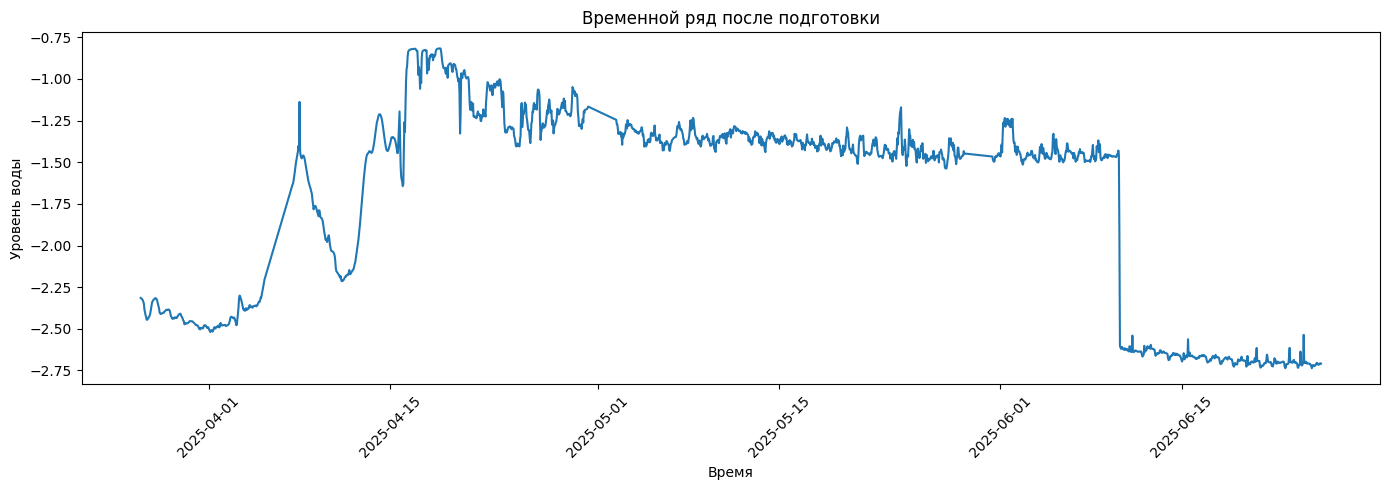

In [ ]:
tmp = df_features.sort_values("datetime")

plt.figure(figsize=(14, 5))
plt.plot(tmp["datetime"], tmp["value"])
plt.title("Временной ряд после подготовки")
plt.xlabel("Время")
plt.ylabel("Уровень воды")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Теперь добавляем простые календарные признаки из времени. Они помогут модели учитывать суточные и календарные эффекты.

In [ ]:
df_features["hour"] = df_features["datetime"].dt.hour
df_features["day"] = df_features["datetime"].dt.day
df_features["month"] = df_features["datetime"].dt.month

df_features.head()

,sensor_id,datetime,value,lag_1,lag_3,lag_6,lag_12,lag_24,lag_48,roll_mean_3,...,roll_mean_12,roll_std_12,roll_mean_24,roll_std_24,roll_mean_48,roll_std_48,target_6h,hour,day,month
48,1.0,2025-03-26 18:00:00,-2.314625,-2.313979,-2.327771,-2.371006,-2.353148,-2.332652,-2.373091,-2.316273,...,-2.352252,0.026405,-2.333509,0.032009,-2.343080,0.030624,-2.350863,18,26,3
49,1.0,2025-03-26 19:00:00,-2.317724,-2.314625,-2.320215,-2.360906,-2.371123,-2.332339,-2.364995,-2.315443,...,-2.347802,0.027416,-2.332900,0.032171,-2.342095,0.030665,-2.384760,19,26,3
50,1.0,2025-03-26 20:00:00,-2.319178,-2.317724,-2.313979,-2.342759,-2.376239,-2.323899,-2.354567,-2.317176,...,-2.343047,0.026980,-2.332704,0.032243,-2.341358,0.030783,-2.401238,20,26,3
51,1.0,2025-03-26 21:00:00,-2.324095,-2.319178,-2.314625,-2.327771,-2.374640,-2.303395,-2.349538,-2.320332,...,-2.338835,0.025505,-2.333566,0.031697,-2.340828,0.030859,-2.417411,21,26,3
52,1.0,2025-03-26 22:00:00,-2.328861,-2.324095,-2.317724,-2.320215,-2.377497,-2.282230,-2.346019,-2.324045,...,-2.334782,0.022489,-2.335509,0.029785,-2.340471,0.030897,-2.427522,22,26,3


Были найдены данные о других погодных признаках, эти данные могут помочь модели научиться делать предсказания

In [ ]:
! gdown 1T7nq1Y7_EZH8pWsOe3A2ZYREoe18zUx0

df_extra = pd.read_csv("dataset_with_external_features.csv")
df_extra.head()

Downloading...
From: https://drive.google.com/uc?id=1T7nq1Y7_EZH8pWsOe3A2ZYREoe18zUx0
To: /content/dataset_with_external_features.csv
100% 1.20M/1.20M [00:00<00:00, 51.3MB/s]


,bridge_id,timestamp,water_level,measurements_in_hour,temperature_2m,temperature_6h_mean,temperature_24h_mean,temperature_diff_24h,relative_humidity_2m,surface_pressure,...,water_level_lag_6h,water_level_lag_12h,water_level_lag_24h,water_level_diff_1h,water_level_diff_6h,water_level_diff_24h,water_level_roll_mean_6h,water_level_roll_mean_24h,water_level_roll_std_24h,water_level_roll_max_24h
0,1,2025-03-24 18:00:00+00:00,-2.373091,41,-4.3,-3.583333,-1.247368,-3.052632,73,981.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2025-03-24 19:00:00+00:00,-2.364995,360,-4.1,-3.850000,-1.390000,-2.710000,73,982.2,...,NaN,NaN,NaN,0.008096,NaN,NaN,-2.373091,-2.373091,NaN,-2.373091
2,1,2025-03-24 20:00:00+00:00,-2.354567,360,-4.5,-4.083333,-1.538095,-2.961905,74,982.6,...,NaN,NaN,NaN,0.010427,NaN,NaN,-2.369043,-2.369043,0.005725,-2.364995
3,1,2025-03-24 21:00:00+00:00,-2.349538,359,-4.5,-4.233333,-1.672727,-2.827273,74,983.3,...,NaN,NaN,NaN,0.005030,NaN,NaN,-2.364218,-2.364218,0.009286,-2.354567
4,1,2025-03-24 22:00:00+00:00,-2.346019,360,-4.8,-4.366667,-1.808696,-2.991304,71,984.3,...,NaN,NaN,NaN,0.003518,NaN,NaN,-2.360548,-2.360548,0.010553,-2.349538


Приводим временные столбцы в обоих датасетах к совместимому формату, чтобы потом корректно соединить данные по времени.

In [ ]:
df_features["datetime"] = pd.to_datetime(df_features["datetime"], errors="coerce")
df_extra["timestamp"] = pd.to_datetime(df_extra["timestamp"], errors="coerce").dt.tz_localize(None)

Здесь выбираем только те внешние признаки, которые действительно хотим добавить в модель. Мы не берем дублирующиеся лаги и rolling по уровню воды, потому что они уже есть в основном датасете.

In [ ]:
df_features = df_features.copy()
df_extra = df_extra.copy()

df_features["datetime"] = pd.to_datetime(df_features["datetime"], errors="coerce")
df_extra["timestamp"] = pd.to_datetime(df_extra["timestamp"], errors="coerce").dt.tz_localize(None)

extra_cols = [
    "bridge_id",
    "timestamp",
    "measurements_in_hour",
    "temperature_2m",
    "temperature_6h_mean",
    "temperature_24h_mean",
    "temperature_diff_24h",
    "relative_humidity_2m",
    "surface_pressure",
    "precipitation",
    "precipitation_1h",
    "precipitation_6h",
    "precipitation_12h",
    "precipitation_24h",
    "precipitation_72h",
    "precipitation_intensity_6h",
    "rain",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_year_sin",
    "day_of_year_cos",
]

df_merged = df_features.merge(
    df_extra[extra_cols],
    left_on=["sensor_id", "datetime"],
    right_on=["bridge_id", "timestamp"],
    how="left"
)

df_merged = df_merged.drop(columns=["bridge_id", "timestamp"], errors="ignore")

print(df_merged.shape)
df_merged.head()

(2027, 45)


,sensor_id,datetime,value,lag_1,lag_3,lag_6,lag_12,lag_24,lag_48,roll_mean_3,...,precipitation_72h,precipitation_intensity_6h,rain,day_of_week,day_of_year,is_weekend,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
0,1.0,2025-03-26 18:00:00,-2.314625,-2.313979,-2.327771,-2.371006,-2.353148,-2.332652,-2.373091,-2.316273,...,5.6,0.0,0.0,2.0,85.0,0.0,-1.000000,-1.836970e-16,0.994218,0.107381
1,1.0,2025-03-26 19:00:00,-2.317724,-2.314625,-2.320215,-2.360906,-2.371123,-2.332339,-2.364995,-2.315443,...,5.6,0.0,0.0,2.0,85.0,0.0,-0.965926,2.588190e-01,0.994218,0.107381
2,1.0,2025-03-26 20:00:00,-2.319178,-2.317724,-2.313979,-2.342759,-2.376239,-2.323899,-2.354567,-2.317176,...,5.6,0.0,0.0,2.0,85.0,0.0,-0.866025,5.000000e-01,0.994218,0.107381
3,1.0,2025-03-26 21:00:00,-2.324095,-2.319178,-2.314625,-2.327771,-2.374640,-2.303395,-2.349538,-2.320332,...,5.6,0.0,0.0,2.0,85.0,0.0,-0.707107,7.071068e-01,0.994218,0.107381
4,1.0,2025-03-26 22:00:00,-2.328861,-2.324095,-2.317724,-2.320215,-2.377497,-2.282230,-2.346019,-2.324045,...,5.6,0.0,0.0,2.0,85.0,0.0,-0.500000,8.660254e-01,0.994218,0.107381


Проверим, где появились пропуски после merge

In [ ]:
df_merged.isna().sum()[df_merged.isna().sum() > 0]

,0
measurements_in_hour,9
temperature_2m,9
temperature_6h_mean,9
temperature_24h_mean,9
temperature_diff_24h,9
relative_humidity_2m,9
surface_pressure,9
precipitation,9
precipitation_1h,9
precipitation_6h,9


Теперь восстанавливаем календарные признаки напрямую из времени и аккуратно заполняем короткие пропуски во внешних погодных признаках.

In [ ]:
df_merged = df_merged.sort_values("datetime").copy()

df_merged["day_of_week"] = df_merged["datetime"].dt.dayofweek
df_merged["day_of_year"] = df_merged["datetime"].dt.dayofyear
df_merged["is_weekend"] = (df_merged["day_of_week"] >= 5).astype(int)

df_merged["hour_sin"] = np.sin(2 * np.pi * df_merged["datetime"].dt.hour / 24)
df_merged["hour_cos"] = np.cos(2 * np.pi * df_merged["datetime"].dt.hour / 24)

df_merged["day_of_year_sin"] = np.sin(2 * np.pi * df_merged["day_of_year"] / 365)
df_merged["day_of_year_cos"] = np.cos(2 * np.pi * df_merged["day_of_year"] / 365)

weather_interp_cols = [
    "temperature_2m",
    "temperature_6h_mean",
    "temperature_24h_mean",
    "temperature_diff_24h",
    "relative_humidity_2m",
    "surface_pressure",
    "precipitation",
    "precipitation_1h",
    "precipitation_6h",
    "precipitation_12h",
    "precipitation_24h",
    "precipitation_72h",
    "precipitation_intensity_6h",
    "measurements_in_hour",
]

df_merged = df_merged.set_index("datetime")

df_merged[weather_interp_cols] = df_merged[weather_interp_cols].interpolate(
    method="time",
    limit_direction="both"
)

df_merged["rain"] = df_merged["rain"].ffill().bfill()

df_merged = df_merged.reset_index()
df_merged["measurements_in_hour"] = df_merged["measurements_in_hour"].round()

print(df_merged.isna().sum()[df_merged.isna().sum() > 0])

Series([], dtype: int64)


Для обучения будем использовать метод раздления данных walk forward

In [ ]:
df_model_6h = df_merged.dropna(subset=feature_cols + ["target_6h"]).copy()
df_model_6h = df_model_6h.sort_values("datetime").reset_index(drop=True)

df_model_6h[["datetime", "target_6h"]].head()

,datetime,target_6h
0,2025-03-26 18:00:00,-2.350863
1,2025-03-26 19:00:00,-2.384760
2,2025-03-26 20:00:00,-2.401238
3,2025-03-26 21:00:00,-2.417411
4,2025-03-26 22:00:00,-2.427522


In [ ]:
min_train_hours = 24 * 30
test_hours = 24 * 7
step_hours = 24 * 7

folds = []

start_time = df_model_6h["datetime"].min()
end_time = df_model_6h["datetime"].max()

train_end = start_time + pd.Timedelta(hours=min_train_hours)

while train_end + pd.Timedelta(hours=test_hours) <= end_time:
    test_start = train_end
    test_end = test_start + pd.Timedelta(hours=test_hours)

    train_df = df_model_6h[df_model_6h["datetime"] < train_end].copy()
    test_df = df_model_6h[
        (df_model_6h["datetime"] >= test_start) &
        (df_model_6h["datetime"] < test_end)
    ].copy()

    if len(train_df) > 0 and len(test_df) > 0:
        folds.append((train_df, test_df))

    train_end = train_end + pd.Timedelta(hours=step_hours)

print("Количество фолдов:", len(folds))

Количество фолдов: 8


In [ ]:
for i, (train_df, test_df) in enumerate(folds, 1):
    print(f"\nFold {i}")
    print("Train:", train_df["datetime"].min(), "->", train_df["datetime"].max(), train_df.shape)
    print("Test :", test_df["datetime"].min(), "->", test_df["datetime"].max(), test_df.shape)


Fold 1
Train: 2025-03-26 18:00:00 -> 2025-04-25 17:00:00 (666, 45)
Test : 2025-04-25 18:00:00 -> 2025-05-02 17:00:00 (114, 45)

Fold 2
Train: 2025-03-26 18:00:00 -> 2025-05-02 17:00:00 (780, 45)
Test : 2025-05-02 18:00:00 -> 2025-05-09 17:00:00 (168, 45)

Fold 3
Train: 2025-03-26 18:00:00 -> 2025-05-09 17:00:00 (948, 45)
Test : 2025-05-09 18:00:00 -> 2025-05-16 17:00:00 (168, 45)

Fold 4
Train: 2025-03-26 18:00:00 -> 2025-05-16 17:00:00 (1116, 45)
Test : 2025-05-16 18:00:00 -> 2025-05-23 17:00:00 (168, 45)

Fold 5
Train: 2025-03-26 18:00:00 -> 2025-05-23 17:00:00 (1284, 45)
Test : 2025-05-23 18:00:00 -> 2025-05-29 08:00:00 (134, 45)

Fold 6
Train: 2025-03-26 18:00:00 -> 2025-05-29 08:00:00 (1418, 45)
Test : 2025-05-31 10:00:00 -> 2025-06-06 17:00:00 (152, 45)

Fold 7
Train: 2025-03-26 18:00:00 -> 2025-06-06 17:00:00 (1570, 45)
Test : 2025-06-06 18:00:00 -> 2025-06-13 17:00:00 (168, 45)

Fold 8
Train: 2025-03-26 18:00:00 -> 2025-06-13 17:00:00 (1738, 45)
Test : 2025-06-13 18:00:00 -> 2

In [ ]:
fold_data = []

for i, (train_df, test_df) in enumerate(folds, 1):
    X_train = train_df[feature_cols]
    y_train = train_df["target_6h"]

    X_test = test_df[feature_cols]
    y_test = test_df["target_6h"]

    fold_data.append({
        "fold": i,
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
    })

print("Подготовлено фолдов:", len(fold_data))

Подготовлено фолдов: 8


В качестве бейзлайна возьмем очень простые метрики: текущее значение и среднее за последние 6 часов

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

baseline_results = []

for fold_item in fold_data:
    fold_num = fold_item["fold"]
    test_df = fold_item["test_df"].copy()
    y_test = fold_item["y_test"]

    pred_persistence = test_df["value"]
    pred_rollmean6 = test_df["roll_mean_6"]

    mae_persistence = mean_absolute_error(y_test, pred_persistence)
    rmse_persistence = np.sqrt(mean_squared_error(y_test, pred_persistence))

    mae_rollmean6 = mean_absolute_error(y_test, pred_rollmean6)
    rmse_rollmean6 = np.sqrt(mean_squared_error(y_test, pred_rollmean6))

    baseline_results.append({
        "fold": fold_num,
        "mae_persistence": mae_persistence,
        "rmse_persistence": rmse_persistence,
        "mae_rollmean6": mae_rollmean6,
        "rmse_rollmean6": rmse_rollmean6,
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

,fold,mae_persistence,rmse_persistence,mae_rollmean6,rmse_rollmean6
0,1,0.074422,0.095887,0.089965,0.103518
1,2,0.038193,0.047026,0.042893,0.052165
2,3,0.026562,0.033417,0.028117,0.033371
3,4,0.040684,0.053617,0.043602,0.054068
4,5,0.058118,0.081128,0.057134,0.079352
5,6,0.042169,0.060255,0.051354,0.067831
6,7,0.061858,0.212782,0.078411,0.242287
7,8,0.017304,0.023915,0.018113,0.023671


In [ ]:
print("Средние метрики по всем фолдам:")
print("Persistence baseline")
print("MAE :", baseline_results_df["mae_persistence"].mean())
print("RMSE:", baseline_results_df["rmse_persistence"].mean())

print("\nRolling mean (6h) baseline")
print("MAE :", baseline_results_df["mae_rollmean6"].mean())
print("RMSE:", baseline_results_df["rmse_rollmean6"].mean())

Средние метрики по всем фолдам:
Persistence baseline
MAE : 0.04491380048683683
RMSE: 0.07600341839600148

Rolling mean (6h) baseline
MAE : 0.05119865909502638
RMSE: 0.08203290299761695


Теперь посмотрим, что будет, если использовать градиентный бустинг

In [ ]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

catboost_results = []
catboost_models = []

for fold_item in fold_data:
    fold_num = fold_item["fold"]

    X_train = fold_item["X_train"]
    y_train = fold_item["y_train"]

    X_test = fold_item["X_test"]
    y_test = fold_item["y_test"]

    model = CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        eval_metric="RMSE",
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
        use_best_model=True
    )

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    catboost_results.append({
        "fold": fold_num,
        "mae_catboost": mae,
        "rmse_catboost": rmse
    })

    catboost_models.append({
        "fold": fold_num,
        "model": model,
        "pred": pred
    })

catboost_results_df = pd.DataFrame(catboost_results)
catboost_results_df

,fold,mae_catboost,rmse_catboost
0,1,0.086499,0.101095
1,2,0.037745,0.047907
2,3,0.024745,0.029988
3,4,0.033994,0.041729
4,5,0.042768,0.064636
5,6,0.045498,0.065474
6,7,0.257158,0.399066
7,8,0.050486,0.059942


In [ ]:
print("Средние метрики CatBoost по всем фолдам:")
print("MAE :", catboost_results_df["mae_catboost"].mean())
print("RMSE:", catboost_results_df["rmse_catboost"].mean())

Средние метрики CatBoost по всем фолдам:
MAE : 0.07236150059434186
RMSE: 0.10122963932846443


In [ ]:
import json

model.save_model("catboost_6h.cbm")

with open("feature_cols_6h.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

In [ ]:
model.save_model("catboost_6h.onnx", format="onnx")